In [36]:
import os
from transformers import AutoProcessor, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import pandas as pd
import logging
import tqdm
import cv2
import Levenshtein
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import warnings
from sklearn.model_selection import train_test_split
import re

warnings.simplefilter(action='ignore', category=FutureWarning)

# Load the Florence-2 Model
model_name = "microsoft/Florence-2-large"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to(device)

mother_path = Path().resolve().parent
data_path = mother_path.joinpath('data')
arg_data = data_path.joinpath('arg_plate_dataset')
arg_train_datapath = arg_data.joinpath('train')
arg_val_datapath = arg_data.joinpath('valid')

In [24]:
# Read img path and label
df_train = pd.read_csv(arg_data/'train_anotaciones.csv')
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = pd.read_csv(arg_data/'valid_anotaciones.csv')

#### One image test

In [3]:
def image_processing(image):
    # This will be the prompt for OCR task with bounding boxes
    prompt = "<OCR_WITH_REGION>"

    # Convert image into tensors
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )

    # Generate the text from the image and parses out the text
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text, task=prompt, image_size=(image.width, image.height)
    )

    return parsed_answer

In [4]:
# Load image
img_path_test = arg_train_datapath/"2020-01-08_1129-09_07_121.png"
image = Image.open(img_path_test).convert("RGB")


ocr_result = image_processing(image)

In [5]:
ocr_result

{'<OCR_WITH_REGION>': {'quad_boxes': [[29.094999313354492,
    25.1564998626709,
    85.74500274658203,
    27.946500778198242,
    84.75499725341797,
    53.98649978637695,
    29.094999313354492,
    51.196502685546875],
   [17.21500015258789,
    52.68450164794922,
    92.78499603271484,
    56.497501373291016,
    92.23500061035156,
    84.30450439453125,
    16.774999618530273,
    81.04949951171875]],
  'labels': ['</s>A04', '5GFS']}}

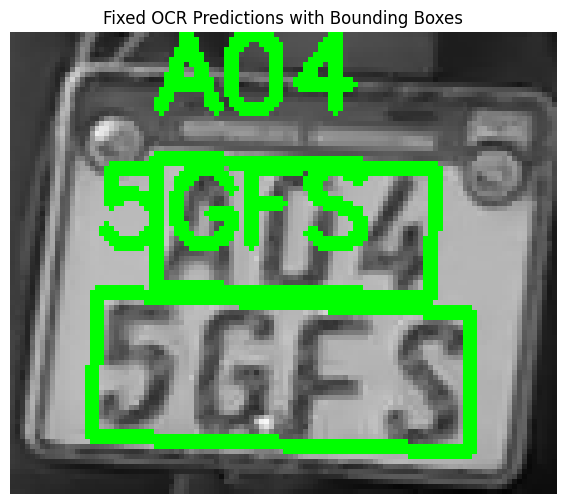

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to OpenCV format
image_cv = np.array(image)
image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR)

# Extract bounding boxes and labels
ocr_data = ocr_result.get("<OCR_WITH_REGION>", {})
boxes = ocr_data.get("quad_boxes", [])
labels = ocr_data.get("labels", [])

# Define OpenCV font
font = cv2.FONT_HERSHEY_SIMPLEX

# Function to clean OCR text output
def clean_ocr_text(text):
    return text.replace("</s>", "").strip()  # Remove unwanted tokens

# Draw bounding boxes and labels
for box, text in zip(boxes, labels):
    text = clean_ocr_text(text)  # Clean the text
    if len(box) < 8:
        continue  # Skip invalid boxes
    
    # Convert coordinates to int (Ensure 4 points are used)
    pts = np.array(box, dtype=np.int32).reshape((-1, 1, 2))
    
    # Draw bounding box
    cv2.polylines(image_cv, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

    # Compute text position
    x, y = pts[0][0]
    
    # Draw text with proper size
    font_scale = 0.7  # Adjust font size
    text_thickness = 2
    cv2.putText(image_cv, text, (x, y - 10), font, font_scale, (0, 255, 0), text_thickness)

# Convert back to RGB (for display)
image_cv = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

# Display image with bounding boxes
plt.figure(figsize=(8, 6))
plt.imshow(image_cv)
plt.axis("off")
plt.title("Fixed OCR Predictions with Bounding Boxes")
plt.show()


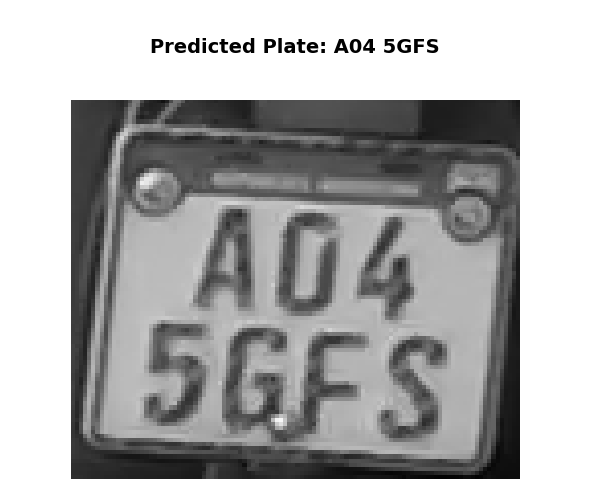

In [21]:
# Convert PIL image to OpenCV format
image_cv = np.array(image)
image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR)

# Extract labels (Predicted plate text)
ocr_data = ocr_result.get("<OCR_WITH_REGION>", {})
labels = ocr_data.get("labels", [])

# Function to clean OCR text output
def clean_ocr_text(text):
    return text.replace("</s>", "").strip()  # Remove unwanted tokens

# Construct the predicted plate text
predicted_plate = "Predicted Plate: " + " ".join(clean_ocr_text(text) for text in labels)

# Create figure with two subplots (reduce text height)
fig, ax = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [0.8, 4]})

# Display the predicted plate as text
ax[0].text(0.5, 0.5, predicted_plate, fontsize=14, ha='center', va='center', fontweight='bold')
ax[0].axis("off")  # Hide axes for text display

# Display the license plate image
image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
ax[1].imshow(image_rgb)
ax[1].axis("off")

# Optimize layout
plt.tight_layout()
plt.show()


#### Preparing dataset

In [ ]:
def img_label(df):
    """
    Extract image path and label pair
    """
    image_paths = [os.path.join(arg_data, img) for img in df['image_path'].tolist()]
    labels = df['plate_text'].tolist()

    return image_paths, labels

train_img, train_labels = img_label(df_train)
val_img, val_labels = img_label(df_val)
test_img, test_labels = img_label(df_test)

#### Testing base model

In [ ]:
def clean_ocr_text(text):
    """Removes special tokens and unwanted characters from OCR output."""
    text = text.replace("</s>", "")  # Remove Florence special token
    text = re.sub(r'[^A-Z0-9]', '', text.upper())  # Keep only A-Z, 0-9
    return text


# Function to compute Character Error Rate (CER)
def character_error_rate(gt, pred):
    """Compute Character Error Rate (CER) using Levenshtein distance."""
    if not gt:  # If ground truth is empty
        return 1.0 if pred else 0.0
    return Levenshtein.distance(gt, pred) / max(len(gt), 1)  # Avoid division by zero

# Initialize accuracy and CER tracking
total_samples = len(test_img)
correct_count = 0
cer_scores = []

# Iterate through test images
for img_path, true_label in tqdm.tqdm(zip(test_img, test_labels), total=total_samples):
    
    # Load image
    image = Image.open(img_path).convert("RGB")

    # Perform OCR using Florence-2
    ocr_result = image_processing(image)

    # Extract predicted text
    predicted_text = ""
    if "<OCR_WITH_REGION>" in ocr_result:
        labels = ocr_result["<OCR_WITH_REGION>"].get("labels", [])
        if labels:
            predicted_text = clean_ocr_text(labels[0])  # Take first detected text

    true_label = clean_ocr_text(true_label)  # Normalize ground truth

    # Compute Accuracy
    if predicted_text == true_label:
        correct_count += 1

    # Compute CER
    cer = character_error_rate(true_label, predicted_text)
    cer_scores.append(cer)

# Compute final accuracy & average CER
accuracy = (correct_count / total_samples) * 100
avg_cer = np.mean(cer_scores)

# Display Results
print(f"✔ Florence-2 OCR Accuracy: {accuracy:.2f}%")
print(f"✔ Florence-2 Average Character Error Rate (CER): {avg_cer:.4f}")

100%|██████████| 763/763 [03:23<00:00,  3.75it/s]

✔ Florence-2 OCR Accuracy: 53.21%
✔ Florence-2 Average Character Error Rate (CER): 0.1874


In [43]:
# Debugging: Print first 10 OCR results
for i, (img_path, true_label) in enumerate(zip(test_img, test_labels)):
    
    if i >= 10:  # Only show first 10 for debugging
        break
    
    # Load image
    image = Image.open(img_path).convert("RGB")

    # Perform OCR using Florence-2
    ocr_result = image_processing(image)

    print(ocr_result)
    # Extract predicted text
    predicted_text = ""
    if "<OCR_WITH_REGION>" in ocr_result:
        labels = ocr_result["<OCR_WITH_REGION>"].get("labels", [])
        if labels:
            predicted_text = clean_ocr_text(labels[0])  # Take first detected text

    true_label = clean_ocr_text(true_label)  # Normalize ground truth

    print(f"🔹 Sample {i+1}")
    print(f"  🔷 True Label      : {true_label}")
    print(f"  🔶 Predicted Text  : {predicted_text}")
    print(f"  🔹 Match?          : {true_label == predicted_text}")
    print("-" * 40)


{'<OCR_WITH_REGION>': {'quad_boxes': [[16.05000114440918, 8.893500328063965, 80.55000305175781, 8.893500328063965, 80.55000305175781, 26.02050018310547, 16.05000114440918, 26.02050018310547]], 'labels': ['</s>DV5-P25']}}
🔹 Sample 1
  🔷 True Label      : DVS325
  🔶 Predicted Text  : DV5P25
  🔹 Match?          : False
----------------------------------------
{'<OCR_WITH_REGION>': {'quad_boxes': [[16.61699867248535, 13.34999942779541, 161.03700256347656, 21.329999923706055, 160.1669921875, 50.849998474121094, 15.920999526977539, 42.869998931884766]], 'labels': ['</s>AC 219 KT']}}
🔹 Sample 2
  🔷 True Label      : AC219KT
  🔶 Predicted Text  : AC219KT
  🔹 Match?          : True
----------------------------------------
{'<OCR_WITH_REGION>': {'quad_boxes': [[15.086501121520996, 9.180500030517578, 135.20651245117188, 11.986499786376953, 134.92050170898438, 43.096500396728516, 15.086501121520996, 40.29050064086914]], 'labels': ['</s>FLG OOZU']}}
🔹 Sample 3
  🔷 True Label      : PLG044
  🔶 Predi